✅ Датасет найден по пути: /home/georgiy/projects/ml/cow/data/raw

=== SPLIT: TRAIN ===
Всего картинок: 4002
Всего файлов разметки: 4002
Картинок без разметки (Background): 0
Файлов разметки без картинок (Битые): 0

=== SPLIT: VAL ===
Всего картинок: 1008
Всего файлов разметки: 1008
Картинок без разметки (Background): 0
Файлов разметки без картинок (Битые): 0



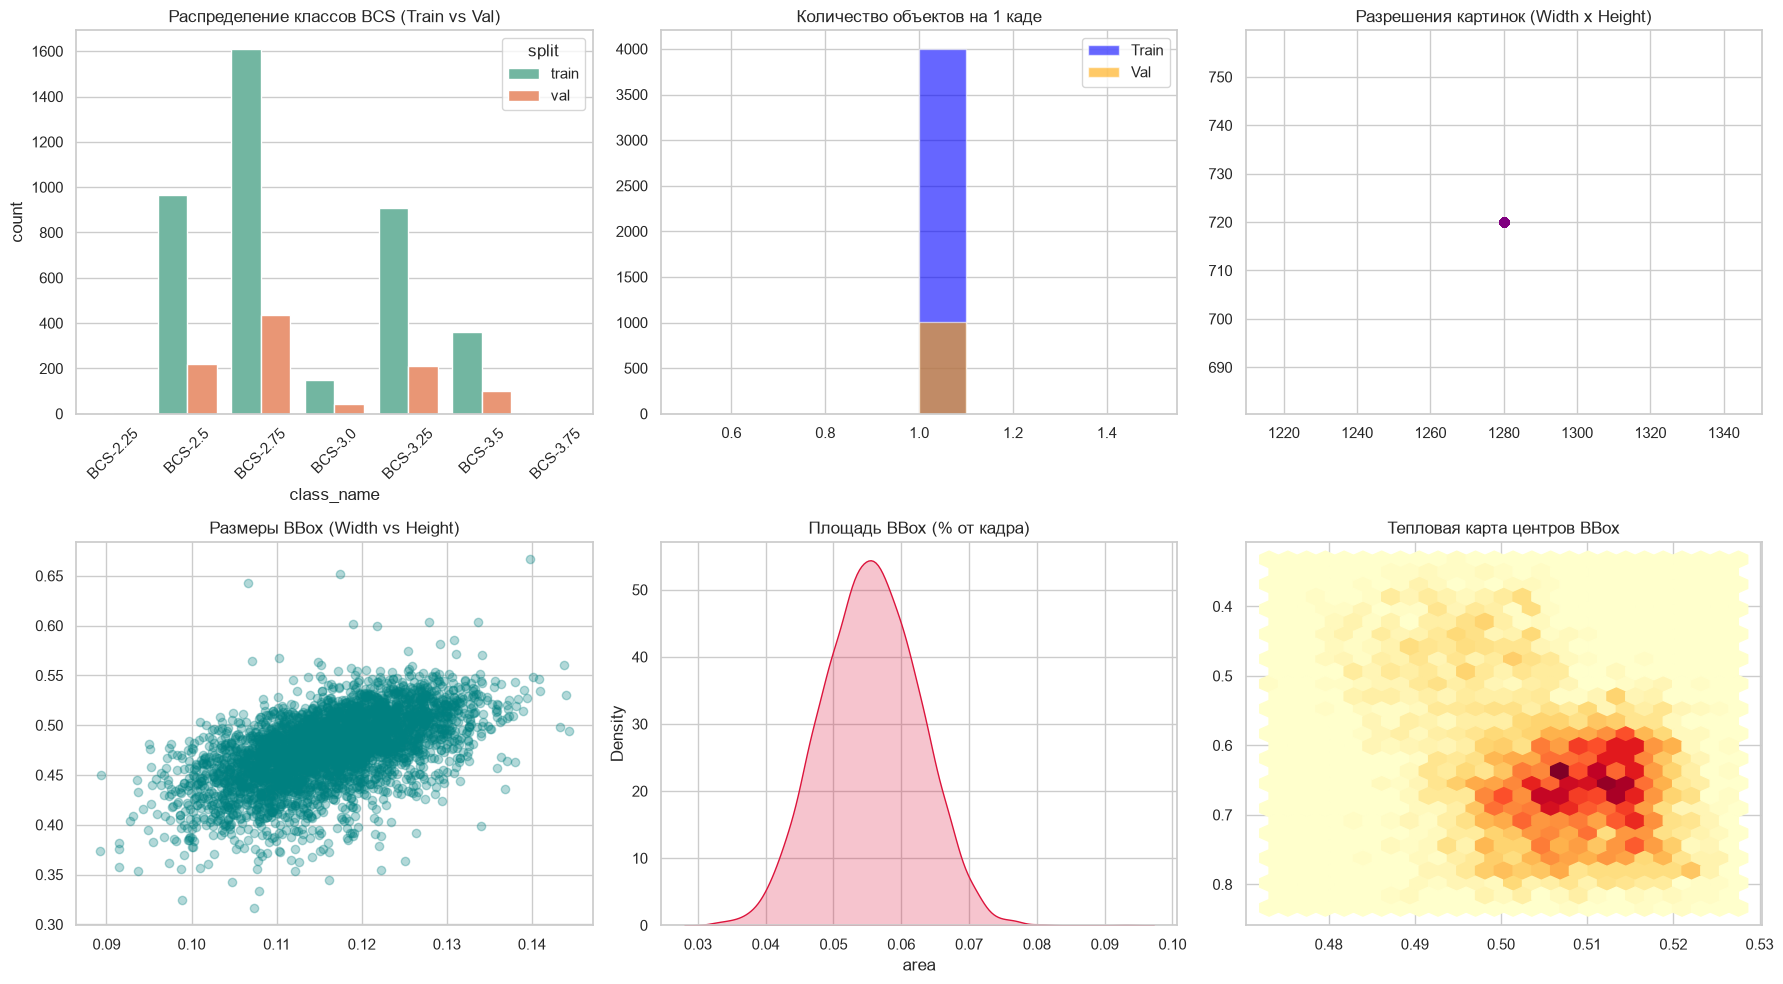

In [7]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import seaborn as sns
import yaml

# --- 1. Определение пути к датасету ---
# Так как текущая папка /home/georgiy/projects/ml/cow, то путь к raw: data/raw
PROJECT_ROOT = Path(os.getcwd())
DATASET_ROOT = PROJECT_ROOT / "data" / "raw"

# Проверка подстраховки, если скрипт запущен из другой директории
if not DATASET_ROOT.exists():
    # Попробуем найти от корня проекта
    POSSIBLE_ROOTS = [
        Path("/home/georgiy/projects/ml/cow/data/raw"),
        Path("../data/raw"),
        Path("data/raw"),
        Path("."),
    ]
    for p in POSSIBLE_ROOTS:
        if (p / "images" / "train").exists():
            DATASET_ROOT = p.resolve()
            break

print(f"✅ Датасет найден по пути: {DATASET_ROOT}\n")

# --- 2. Чтение классов из data.yaml ---
YAML_FILE = DATASET_ROOT / "data.yaml"
class_map = {}

if YAML_FILE.exists():
    with open(YAML_FILE, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)
        names = config.get("names", {})
        if isinstance(names, dict):
            class_map = {int(k): v for k, v in names.items()}
        elif isinstance(names, list):
            class_map = {i: name for i, name in enumerate(names)}


# --- 3. Парсинг сплитов (train / val) ---
def analyze_split(split_name="train"):
    img_dir = DATASET_ROOT / "images" / split_name
    lbl_dir = DATASET_ROOT / "labels" / split_name

    extensions = ("*.webp", "*.jpg", "*.jpeg", "*.png")
    img_files = []
    for ext in extensions:
        img_files.extend(list(img_dir.glob(ext)))

    lbl_files = list(lbl_dir.glob("*.txt"))

    img_basenames = {f.stem: f for f in img_files}
    lbl_basenames = {f.stem: f for f in lbl_files}

    missing_labels = set(img_basenames.keys()) - set(lbl_basenames.keys())
    missing_images = set(lbl_basenames.keys()) - set(img_basenames.keys())

    print(f"=== SPLIT: {split_name.upper()} ===")
    print(f"Всего картинок: {len(img_files)}")
    print(f"Всего файлов разметки: {len(lbl_files)}")
    print(f"Картинок без разметки (Background): {len(missing_labels)}")
    print(
        f"Файлов разметки без картинок (Битые): {len(missing_images)}\n"
    )

    bboxes = []
    objects_count = []
    image_sizes = []

    # Разрешения изображений
    for img_path in img_files:
        try:
            with Image.open(img_path) as img:
                image_sizes.append(img.size)  # (w, h)
        except Exception as e:
            print(f"Ошибка чтения {img_path.name}: {e}")

    # Парсинг Bounding Box'ов
    for stem, lbl_path in lbl_basenames.items():
        if stem not in img_basenames:
            continue

        with open(lbl_path, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]
            objects_count.append(len(lines))

            for line in lines:
                parts = line.split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    xc, yc, w, h = map(float, parts[1:5])
                    bboxes.append(
                        {
                            "split": split_name,
                            "class_id": cls_id,
                            "class_name": class_map.get(
                                cls_id, f"BCS-{cls_id}"
                            ),
                            "x_center": xc,
                            "y_center": yc,
                            "width": w,
                            "height": h,
                            "area": w * h,
                        }
                    )

    return pd.DataFrame(bboxes), objects_count, image_sizes


# --- 4. Сбор метрик ---
df_train, train_obj_cnt, train_sizes = analyze_split("train")
df_val, val_obj_cnt, val_sizes = analyze_split("val")

df_all = pd.concat([df_train, df_val], ignore_index=True)

# --- 5. Отрисовка графиков ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Распределение классов BCS
if not df_all.empty:
    sorted_classes = [
        class_map[i] for i in sorted(class_map.keys()) if i in class_map
    ]
    sns.countplot(
        data=df_all,
        x="class_name",
        hue="split",
        order=[c for c in sorted_classes if c in df_all["class_name"].unique()],
        ax=axes[0, 0],
        palette="Set2",
    )
    axes[0, 0].set_title("Распределение классов BCS (Train vs Val)")
    axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Количество объектов на кадр
if train_obj_cnt or val_obj_cnt:
    if train_obj_cnt:
        axes[0, 1].hist(
            train_obj_cnt, bins=10, alpha=0.6, label="Train", color="blue"
        )
    if val_obj_cnt:
        axes[0, 1].hist(
            val_obj_cnt, bins=10, alpha=0.6, label="Val", color="orange"
        )
    axes[0, 1].set_title("Количество объектов на 1 каде")
    axes[0, 1].legend()

# 3. Разрешение картинок
if train_sizes:
    ws, hs = zip(*train_sizes)
    axes[0, 2].scatter(ws, hs, alpha=0.5, color="purple")
    axes[0, 2].set_title("Разрешения картинок (Width x Height)")

# 4. Размеры BBox
if not df_train.empty:
    axes[1, 0].scatter(
        df_train["width"], df_train["height"], alpha=0.3, c="teal"
    )
    axes[1, 0].set_title("Размеры BBox (Width vs Height)")

# 5. Площадь BBox
if not df_train.empty:
    sns.kdeplot(df_train["area"], ax=axes[1, 1], fill=True, color="crimson")
    axes[1, 1].set_title("Площадь BBox (% от кадра)")

# 6. Центры BBox
if not df_train.empty:
    axes[1, 2].hexbin(
        df_train["x_center"], df_train["y_center"], gridsize=25, cmap="YlOrRd"
    )
    axes[1, 2].set_title("Тепловая карта центров BBox")
    axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()

📊 СТАТИСТИКА КЛАССОВ В TRAIN (Всего объектов: 4002)
 Class ID  BCS Score    Label  Count Percentage (%)
        0       1.00  BCS-1.0      0          0.00%
        1       1.25 BCS-1.25      0          0.00%
        2       1.50  BCS-1.5      0          0.00%
        3       1.75 BCS-1.75      0          0.00%
        4       2.00  BCS-2.0      0          0.00%
        5       2.25 BCS-2.25      3          0.07%
        6       2.50  BCS-2.5    966         24.14%
        7       2.75 BCS-2.75   1611         40.25%
        8       3.00  BCS-3.0    148          3.70%
        9       3.25 BCS-3.25    910         22.74%
       10       3.50  BCS-3.5    362          9.05%
       11       3.75 BCS-3.75      2          0.05%
       12       4.00  BCS-4.0      0          0.00%
       13       4.25 BCS-4.25      0          0.00%
       14       4.50  BCS-4.5      0          0.00%
       15       4.75 BCS-4.75      0          0.00%
       16       5.00  BCS-5.0      0          0.00%

📈 ЧИСЛОВЫЕ 

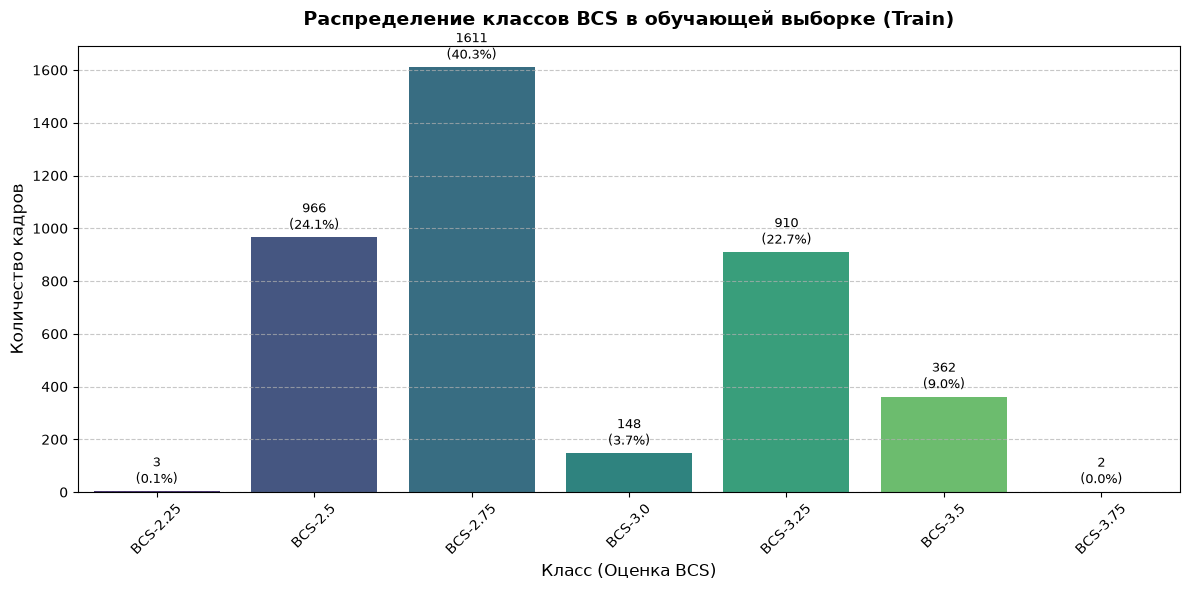

In [1]:
import os
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# --- 1. Пути ---
DATASET_ROOT = Path("data/raw") # или заменяй на абсолютный путь, если нужно
YAML_FILE = DATASET_ROOT / "data.yaml"

# Маппинг ID класса -> BCS значение
class_to_bcs = {
    0: 1.0, 1: 1.25, 2: 1.5, 3: 1.75, 4: 2.0, 5: 2.25, 6: 2.5,
    7: 2.75, 8: 3.0, 9: 3.25, 10: 3.5, 11: 3.75, 12: 4.0, 13: 4.25,
    14: 4.5, 15: 4.75, 16: 5.0
}

# Имена для красивого вывода (например, "BCS-2.75")
class_names = {k: f"BCS-{v}" for k, v in class_to_bcs.items()}

# --- 2. Чтение файлов разметки train ---
train_lbl_dir = DATASET_ROOT / "labels" / "train"
lbl_files = list(train_lbl_dir.glob("*.txt"))

train_classes = []
train_bcs_values = []

for lbl_path in lbl_files:
    with open(lbl_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                train_classes.append(cls_id)
                train_bcs_values.append(class_to_bcs.get(cls_id, cls_id))

# --- 3. Сводная таблица ---
df_summary = pd.DataFrame({"class_id": train_classes, "bcs_score": train_bcs_values})
counts = df_summary["class_id"].value_counts().sort_index()

stats_list = []
total_samples = len(train_classes)

for cls_id in range(17):  # Проходим по всем возможным классам 0..16
    cnt = counts.get(cls_id, 0)
    pct = (cnt / total_samples) * 100 if total_samples > 0 else 0
    stats_list.append({
        "Class ID": cls_id,
        "BCS Score": class_to_bcs.get(cls_id),
        "Label": class_names.get(cls_id),
        "Count": cnt,
        "Percentage (%)": f"{pct:.2f}%"
    })

df_stats = pd.DataFrame(stats_list)

print("=" * 60)
print(f"📊 СТАТИСТИКА КЛАССОВ В TRAIN (Всего объектов: {total_samples})")
print("=" * 60)
print(df_stats.to_string(index=False))

# --- 4. Статистика BCS как непрерывной величины ---
print("\n" + "=" * 60)
print("📈 ЧИСЛОВЫЕ МЕТРИКИ BCS (как непрерывной переменной)")
print("=" * 60)
print(f"Среднее значение (Mean BCS):   {df_summary['bcs_score'].mean():.3f}")
print(f"Медиана (Median BCS):          {df_summary['bcs_score'].median():.3f}")
print(f"Ст. отклонение (Std Dev):       {df_summary['bcs_score'].std():.3f}")
print(f"Минимум / Максимум:            {df_summary['bcs_score'].min()} / {df_summary['bcs_score'].max()}")

# --- 5. Визуализация ---
plt.figure(figsize=(12, 6))
df_present = df_stats[df_stats["Count"] > 0] # Отобразим только присутствующие классы

ax = sns.barplot(
    data=df_present, 
    x="Label", 
    y="Count", 
    palette="viridis",
    hue="Label",
    legend=False
)

plt.title("Распределение классов BCS в обучающей выборке (Train)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Класс (Оценка BCS)", fontsize=12)
plt.ylabel("Количество кадров", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Добавляем числа над барами
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(
            f'{height}\n({(height/total_samples)*100:.1f}%)',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9,
            xytext=(0, 3),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

Ищем разметку в директории: /home/georgiy/projects/ml/cow/data/raw/labels/train
✅ Найден файл: 39636__7610_115_1_19-05-24-21-31-34-6.webp для класса 3.75
✅ Найден файл: 0000_50_1_30-09-24-11-07-00-3.webp для класса 2.25
✅ Найден файл: 39636__7610_115_1_19-05-24-21-31-35-7.webp для класса 3.75
✅ Найден файл: 0000_50_1_29-09-24-05-41-13-8.webp для класса 2.25
✅ Найден файл: 7357_116_1_05-06-24-06-33-57-6.webp для класса 2.25

Отрисовываем 3 фото для класса BCS 2.25


AttributeError: 'Text' object has no property 'pad'

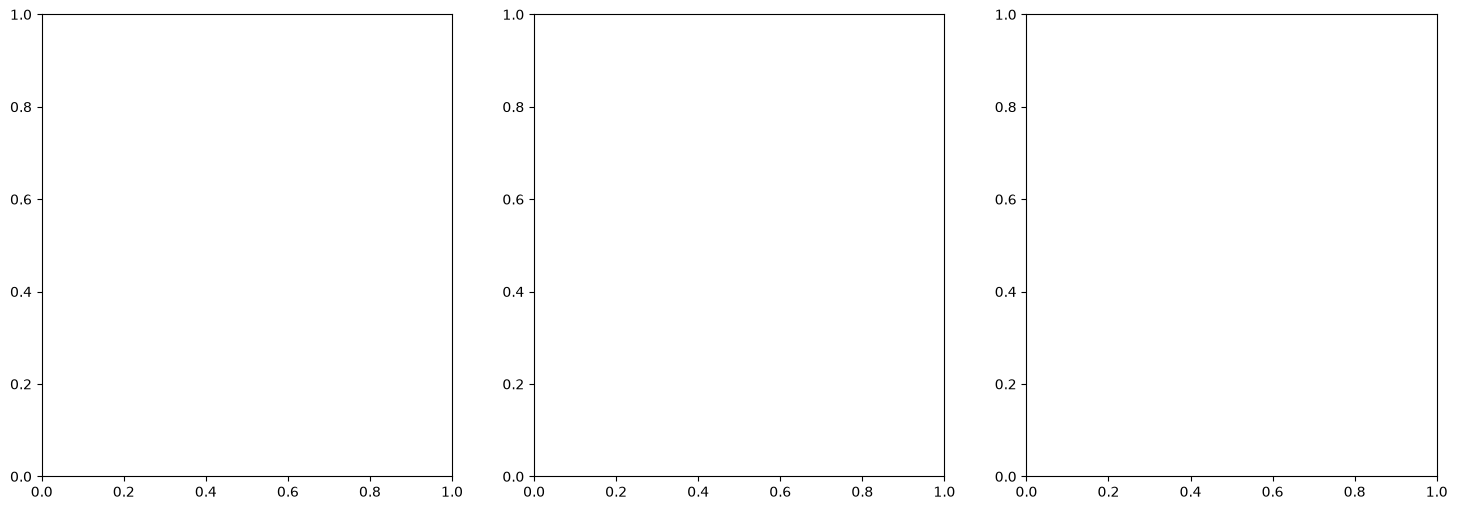

In [3]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

# --- 1. Указываем АБСОЛЮТНЫЙ путь к вашим данным ---
DATASET_ROOT = Path("/home/georgiy/projects/ml/cow/data/raw") 
TRAIN_LBL_DIR = DATASET_ROOT / "labels" / "train"
TRAIN_IMG_DIR = DATASET_ROOT / "images" / "train" 

target_classes = {
    5: 2.25,
    11: 3.75
}

def show_rare_yolo_images_absolute(lbl_dir, img_dir, targets):
    found_images = {score: [] for score in targets.values()}
    print(f"Ищем разметку в директории: {lbl_dir}")
    
    lbl_files = list(lbl_dir.glob("*.txt"))
    if not lbl_files:
        print(f"❌ В папке {lbl_dir} не найдено txt-файлов!")
        return

    # --- 2. Поиск файлов ---
    for lbl_path in lbl_files:
        with open(lbl_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                
                cls_id = int(parts[0])
                
                if cls_id in targets:
                    bcs_score = targets[cls_id]
                    base_name = lbl_path.stem # Имя файла (например, 0000_4_1_01-07-24-19-42-37-3)
                    
                    # Прямо ищем файл .webp в папке images/train
                    img_path = img_dir / f"{base_name}.webp"
                    
                    if img_path.exists() and img_path not in found_images[bcs_score]:
                        found_images[bcs_score].append(img_path)
                        print(f"✅ Найден файл: {img_path.name} для класса {bcs_score}")

    # --- 3. Отрисовка ---
    for score, img_paths in found_images.items():
        num_images = len(img_paths)
        if num_images == 0:
            print(f"❌ Картинки для BCS {score} не найдены.")
            continue
            
        print(f"\nОтрисовываем {num_images} фото для класса BCS {score}")
        
        # Динамический размер окна в зависимости от количества фото
        fig, axes = plt.subplots(1, num_images, figsize=(6 * num_images, 6))
        if num_images == 1:
            axes = [axes]
            
        fig.suptitle(f'Редкие кадры: Оценка BCS {score}', fontsize=16, fontweight='bold', pad=20)
        
        for ax, path in zip(axes, img_paths):
            try:
                img = Image.open(path)
                ax.imshow(img)
                ax.axis('off')
                ax.set_title(path.name, fontsize=9)
            except Exception as e:
                ax.text(0.5, 0.5, f'Ошибка загрузки\n{path.name}', ha='center', va='center', color='red')
                ax.axis('off')
                
        plt.tight_layout()
        plt.show()

show_rare_yolo_images_absolute(TRAIN_LBL_DIR, TRAIN_IMG_DIR, target_classes)